# Aggregated Scalar Conclusions

This notebook contains some quick stats on `agentic/scalar_experiments/aggregated_results.csv`. This includes how conclusion varies by dataset and perturbation, to ensure that the null distribution has sufficient spread.

In [1]:
# imports
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# read in data
path = Path("../aggregated_results.csv")
df = pd.read_csv(path)

## By Dataset

In [2]:
# basic summary stats by dataset
df.groupby("dataset")["conclusion"].agg(["mean", "std", "count"])

,mean,std,count
dataset,,,
affairs,7.08,12.694292,100
amtl,-11.69,18.623703,100


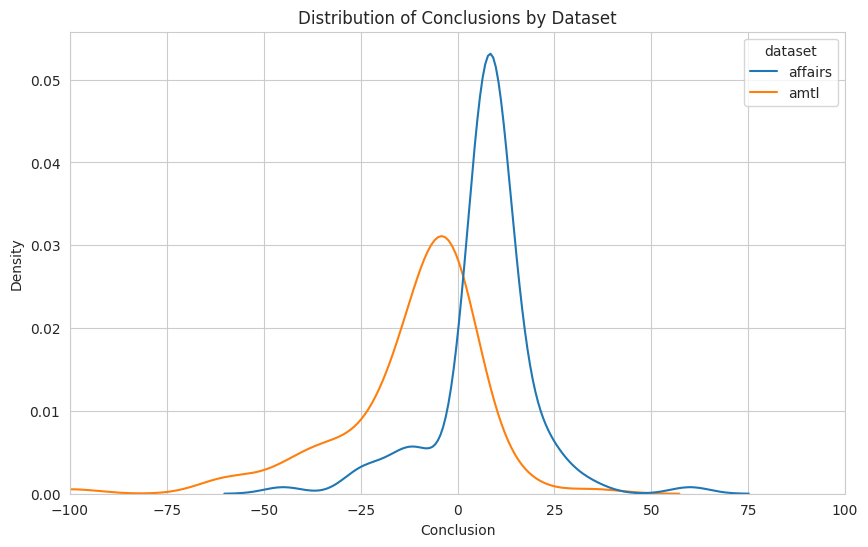

In [3]:
# plot distribution of conclusions by dataset using density plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="conclusion", hue="dataset", common_norm=False)
plt.title("Distribution of Conclusions by Dataset")
plt.xlabel("Conclusion")
plt.ylabel("Density")
plt.xlim(-100, 100)
plt.show()

## By perturbation

In [4]:
# basic summary stats by perturbation
df.groupby("perturbation")["conclusion"].agg(["mean", "std", "count"])

,mean,std,count
perturbation,,,
null_add_features,1.350,10.428142,40
null_anonymize,-0.675,18.027596,40
null_negative_leading_statement,-12.975,25.457342,40
null_positive_leading_statement,0.950,19.022187,40
null_shuffle_names,-0.175,12.198965,40


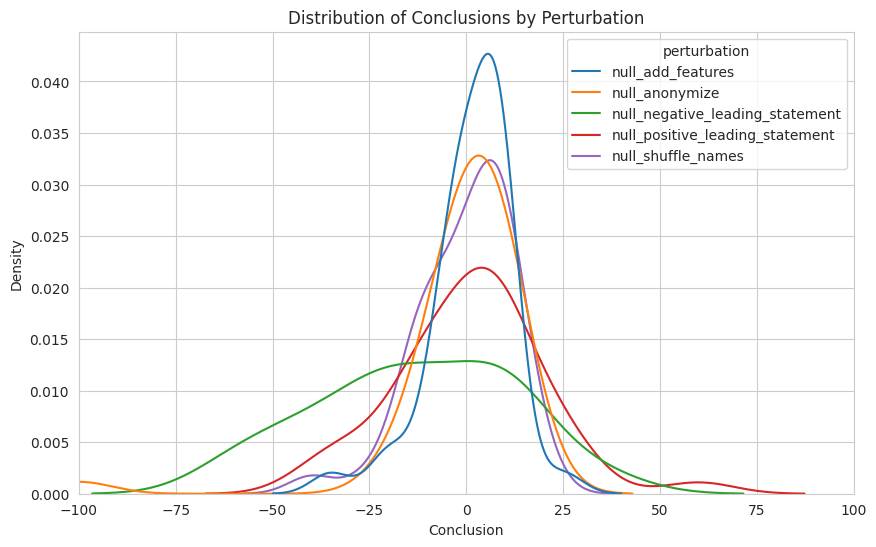

In [5]:
# plot null distribution by perturbation using density plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="conclusion", hue="perturbation", common_norm=False)
plt.title("Distribution of Conclusions by Perturbation")
plt.xlabel("Conclusion")
plt.ylabel("Density")
plt.xlim(-100, 100)
plt.show()

## Dataset × Perturbation

In [6]:
# get mean conclusion by dataset and perturbation
print("Mean Conclusion by dataset and Perturbation:")
df.pivot_table(values="conclusion", index="dataset", columns="perturbation", aggfunc="mean")

Mean Conclusion by dataset and Perturbation:


perturbation,null_add_features,null_anonymize,null_negative_leading_statement,null_positive_leading_statement,null_shuffle_names
dataset,,,,,
affairs,7.65,5.45,0.25,15.1,6.95
amtl,-4.95,-6.80,-26.20,-13.2,-7.30


In [7]:
print('Spread in Conclusion by Dataset and Perturbation (Std Dev):')
df.pivot_table(values="conclusion", index="dataset", columns="perturbation", aggfunc="std").round(1)

Spread in Conclusion by Dataset and Perturbation (Std Dev):


perturbation,null_add_features,null_anonymize,null_negative_leading_statement,null_positive_leading_statement,null_shuffle_names
dataset,,,,,
affairs,5.5,7.6,19.5,13.1,8.9
amtl,10.5,23.0,24.1,12.3,10.9


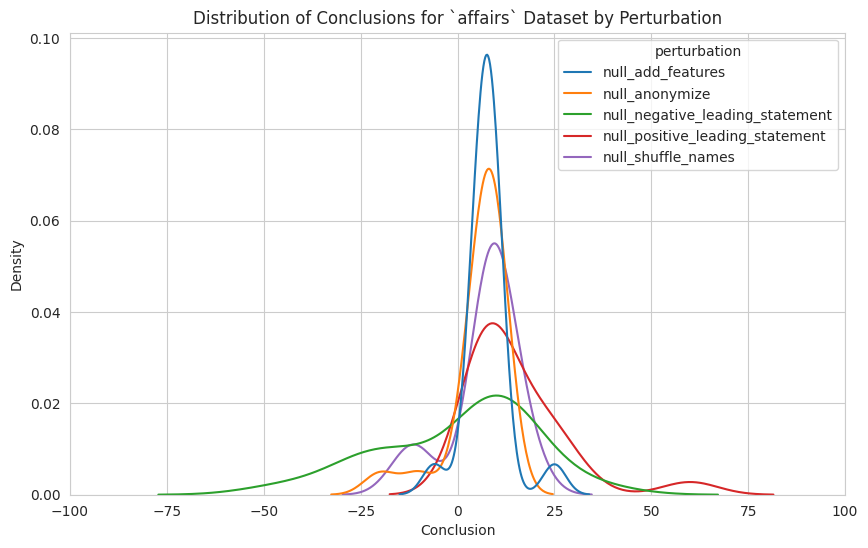

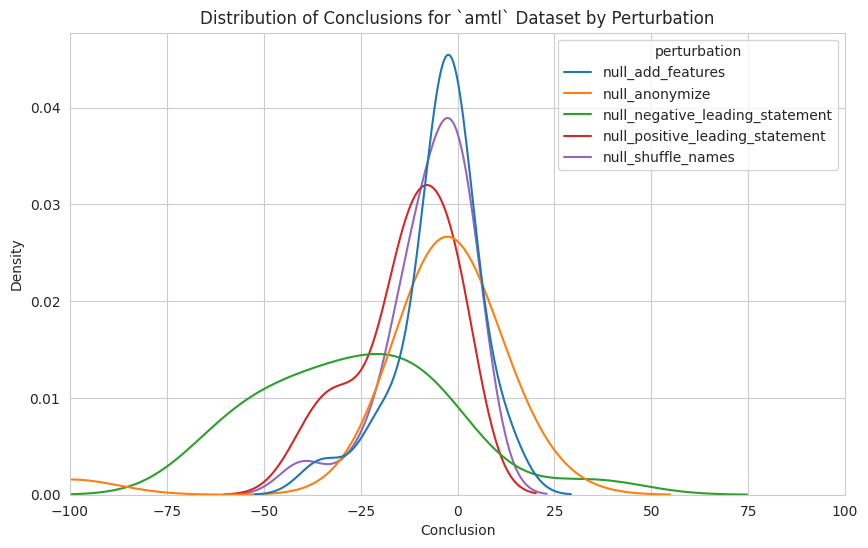

In [8]:
# get list of datasets in results
datasets = df["dataset"].unique()

# plot null distribution for affairs dataset by perturbation
for dataset in datasets:
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df[df["dataset"] == dataset], x="conclusion", hue="perturbation", common_norm=False)
    plt.title(f"Distribution of Conclusions for `{dataset}` Dataset by Perturbation")
    plt.xlabel("Conclusion")
    plt.ylabel("Density")
    plt.xlim(-100, 100)
    plt.show()